In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

In [2]:
sheet_id = "1QGYAfhy8trzrWV-gpVjIUNIhc146733m0Cv_pCRYQpc"

sheet_desember_2025 = "Desember_2025"
sheet_january_2026 = "January_2026"
sheet_february_2026 = "February_2026"

In [3]:
url_desember_2025 = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_desember_2025}"
url_january_2026 = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_january_2026}"
url_february_2026 = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_february_2026}"

In [4]:
df_desember_2025 = pd.read_csv(url_desember_2025)
df_january_2026 = pd.read_csv(url_january_2026)
df_february_2026 = pd.read_csv(url_february_2026)

In [5]:
concat_df = pd.concat([df_desember_2025, df_january_2026, df_february_2026],ignore_index=True)
concat_df = concat_df[['Date', 'Code', 'Name', 'Action', 'Shares Traded', 'Current','Previous', 'Price', 'Broker', 'Type']]
df = concat_df
df

,Date,Code,Name,Action,Shares Traded,Current,Previous,Price,Broker,Type
0,01 Dec 25,HALO,PROMOSI DESA DIGITAL\n\nSumber: IDX,WARRANT EXERCISE,"40,000,000+0.6500%","298,162,0005.0800%","258,162,0004.4300%",150,-,D
1,01 Dec 25,BFIN,IWAN\n\nSumber: IDX,BUY,"350,000+0.0023%","2,000,0000.0133%","1,650,0000.0110%",750,-,D
2,01 Dec 25,KETR,BAHTERA BINTANG NUSANTARAP\n\nSumber: IDX,SELL,"50,000-0.0018%","84,772,1002.9836%","84,822,1002.9854%",615,-,D
3,01 Dec 25,KETR,BAHTERA BINTANG NUSANTARAP\n\nSumber: IDX,SELL,"150,000-0.0052%","84,822,1002.9854%","84,972,1002.9906%",610,-,D
4,01 Dec 25,KETR,BAHTERA BINTANG NUSANTARAP\n\nSumber: IDX,SELL,"492,700-0.0174%","84,972,1002.9906%","85,464,8003.0080%",605,-,D
...,...,...,...,...,...,...,...,...,...,...
3894,02/02/2026,BIPP,SAFIRE CAPITALP\n\nSumber: IDX,SELL,"61,635,000-1.2200%","3,098,530,19561.6200%","3,160,165,19562.8400%",81,-,F
3895,02/02/2026,BIPP,SAFIRE CAPITALP\n\nSumber: KSEI,SELL,"184,907,000-3.6770%","3,160,165,19562.8430%","3,345,072,19566.5200%",-,MI,F
3896,02/02/2026,ARNA,SUPRAKREASI ERADINAMIKA\n\nSumber: KSEI,BUY,"800,000+0.0109%","1,087,463,20014.8127%","1,086,663,20014.8018%",-,DR,D
3897,02/02/2026,BBLD,BANK OF SINGAPORE\n\nSumber: KSEI,BUY,"50,000+0.0031%","89,637,6005.4465%","89,587,6005.4434%",-,-,F


In [6]:
def clean_insider_dataframe(df):

    df = df.copy()

    # CLEAN COLUMN NAMES
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(" ", "_")
    )

    # DATE PARSING (mixed format)
    def parse_mixed_date(x):
        try:
            return pd.to_datetime(x, format="%d %b %y")
        except:
            try:
                return pd.to_datetime(x, format="%d/%m/%Y")
            except:
                return pd.to_datetime(x, errors="coerce")

    df["date"] = df["date"].apply(parse_mixed_date)

    # NUMERIC EXTRACTORS
    def extract_number(x):
        if pd.isna(x):
            return np.nan
        x = str(x).replace(",", "")
        match = re.search(r"[-+]?\d*\.?\d+", x)
        return float(match.group()) if match else np.nan

    def extract_percent(x):
        if pd.isna(x):
            return np.nan
        x = str(x)
        match = re.search(r"([-+]?\d*\.?\d+)%", x)
        return float(match.group(1)) if match else np.nan

    # SHARES TRADED PARSING
    # contoh: "40,000,000+0.6500%"
    df["shares_traded_clean"] = (
        df["shares_traded"]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.extract(r"(\d+)")
            .astype(float)
    )

    df["ownership_change_pct"] = df["shares_traded"].apply(extract_percent)

    # OWNERSHIP BEFORE / AFTER
    # contoh: 298,162,0005.0800%
    def split_shares_percent(x):
        if pd.isna(x):
            return pd.Series([np.nan, np.nan])
        x = str(x).replace(",", "")
        match = re.match(r"(\d+)([-+]?\d*\.?\d+)%", x)
        if match:
            return pd.Series([float(match.group(1)), float(match.group(2))])
        return pd.Series([np.nan, np.nan])

    df[["ownership_after_shares", "ownership_after_pct"]] = df["current"].apply(split_shares_percent)
    df[["ownership_before_shares", "ownership_before_pct"]] = df["previous"].apply(split_shares_percent)

    # PRICE CLEANING
    df["price_clean"] = df["price"].apply(extract_number)

    # ACTION STANDARDIZATION
    def normalize_action(x):
        x = str(x).lower()
        if "buy" in x:
            return "buy"
        elif "sell" in x:
            return "sell"
        elif "transfer" in x:
            return "transfer"
        elif "exercise" in x:
            return "exercise"
        else:
            return "other"

    df["action_clean"] = df["action"].apply(normalize_action)

    df["is_corporate_action"] = df["action_clean"].isin(["exercise", "transfer"])

    # ACTOR NAME NORMALIZATION
    def normalize_actor_name(x):
        if pd.isna(x):
            return None
        x = str(x)
        x = x.replace("\n", " ")
        x = re.sub(r"Sumber:.*", "", x, flags=re.IGNORECASE)
        x = re.sub(r"[\"']", "", x)
        x = re.sub(r"[.,]", "", x)
        x = re.sub(r"\s+", " ", x)
        return x.strip().upper()

    df["actor_name_clean"] = df["name"].apply(normalize_actor_name)

    # Canonical mapping
    canonical_map = {
        "J P MORGAN": "JP MORGAN",
        "JPMORGAN": "JP MORGAN",
        "JPMORGAN CHASE & CO": "JP MORGAN",
        "GLENCORE INTERNATIONAL INVESTMENTS LTD": "GLENCORE",
    }

    def canonicalize_actor(name):
        if pd.isna(name):
            return name
        for key in canonical_map:
            if key in name:
                return canonical_map[key]
        return name

    df["actor_name_final"] = df["actor_name_clean"].apply(canonicalize_actor)

    # ACTOR TYPE CLASSIFICATION
    def classify_actor(row):
        name = str(row["actor_name_final"]).lower()
        if "sekuritas" in name:
            return "broker"
        elif "ltd" in name or "investments" in name:
            return "institution"
        elif row.get("type") == "F":
            return "foreign"
        else:
            return "individual"

    df["actor_type"] = df.apply(classify_actor, axis=1)

    # DERIVED METRICS
    df["transaction_value"] = df["shares_traded_clean"] * df["price_clean"]

    df["ownership_change_abs"] = (
        df["ownership_after_pct"] - df["ownership_before_pct"]
    )

    # FINAL DATAFRAME
    clean_cols = [
        "date",
        "code",
        "actor_name_final",
        "actor_type",
        "action_clean",
        "shares_traded_clean",
        "price_clean",
        "transaction_value",
        "ownership_before_pct",
        "ownership_after_pct",
        "ownership_change_abs",
        "is_corporate_action"
    ]

    df_clean = (
        df[clean_cols]
        .sort_values("date")
        .reset_index(drop=True)
    )

    return df_clean


In [7]:
df_clean = clean_insider_dataframe(concat_df)

df_clean

,date,code,actor_name_final,actor_type,action_clean,shares_traded_clean,price_clean,transaction_value,ownership_before_pct,ownership_after_pct,ownership_change_abs,is_corporate_action
0,2025-12-01,HALO,PROMOSI DESA DIGITAL,individual,exercise,40000000.0,150.0,6.000000e+09,0.4300,0.0800,-0.3500,True
1,2025-12-01,MSIN,MEDIA NUSANTARA CITRAP,individual,sell,500000.0,NaN,NaN,0.6070,0.6062,-0.0008,False
2,2025-12-01,ITMA,MAJUKARYA MANDIRI INDONESIA,individual,buy,17494800.0,NaN,NaN,NaN,0.7511,NaN,False
3,2025-12-01,ITMA,MAJUKARYA MANDIRI INDONESIA,individual,buy,13279300.0,NaN,NaN,0.7511,0.0803,-0.6708,False
4,2025-12-01,ITMA,MAJUKARYA MANDIRI INDONESIA,individual,buy,1529000.0,NaN,NaN,0.0803,0.2334,0.1531,False
...,...,...,...,...,...,...,...,...,...,...,...,...
3894,2026-02-11,COCO,DBS BANK LTD SG-PB CLIENTS,institution,buy,6784500.0,NaN,NaN,0.0494,0.2400,0.1906,False
3895,2026-02-12,TIRT,HARITA JAYARAYAP,individual,sell,10241700.0,665.0,6.810730e+09,0.1419,0.1297,-0.0122,False
3896,2026-02-12,IRSX,MATRA TRI ABADIP,individual,buy,113190000.0,570.0,6.451830e+10,0.9800,0.8000,-0.1800,False
3897,2026-02-12,MDKA,ANDREW PHILLIP STARKEYK,foreign,buy,300000.0,3113.0,9.339000e+08,0.0140,0.0150,0.0010,False


# BASIC TRANSACTION FEATURES

In [8]:
# pastikan numeric
df_clean["shares_traded_clean"] = pd.to_numeric(df_clean["shares_traded_clean"], errors="coerce")
df_clean["price_clean"] = pd.to_numeric(df_clean["price_clean"], errors="coerce")
df_clean["transaction_value"] = pd.to_numeric(df_clean["transaction_value"], errors="coerce")

# Absolute ownership change
df_clean["ownership_change_abs"] = (
    df_clean["ownership_after_pct"] - df_clean["ownership_before_pct"]
)

# Directional flag
df_clean["net_direction"] = df_clean["action_clean"].map({
    "buy": 1,
    "sell": -1
}).fillna(0)

# Net value signed
df_clean["signed_transaction_value"] = (
    df_clean["transaction_value"] * df_clean["net_direction"]
)

# ACTOR AGGREGATION FEATURES

In [9]:
actor_stats = (
    df_clean
    .groupby("actor_name_final")
    .agg(
        total_transactions=("code", "count"),
        total_value=("transaction_value", "sum"),
        net_value=("signed_transaction_value", "sum"),
        unique_tickers=("code", "nunique"),
        total_shares=("shares_traded_clean", "sum")
    )
    .reset_index()
)

# join kembali ke main df
df_clean = df_clean.merge(
    actor_stats,
    on="actor_name_final",
    how="left",
    suffixes=("", "_actor")
)


# CLUSTER BUY DETECTION

In [10]:
df_clean = df_clean.sort_values(["actor_name_final", "date"])

df_clean["cluster_buy_30d"] = 0

for actor in df_clean["actor_name_final"].unique():
    mask = df_clean["actor_name_final"] == actor
    actor_df = df_clean[mask]
    
    for idx in actor_df.index:
        current_date = df_clean.loc[idx, "date"]
        
        window = actor_df[
            (actor_df["date"] >= current_date - pd.Timedelta(days=30)) &
            (actor_df["date"] <= current_date) &
            (actor_df["action_clean"] == "buy")
        ]
        
        df_clean.loc[idx, "cluster_buy_30d"] = len(window)


# OWNERSHIP INTENSITY

In [11]:
df_clean["ownership_level_flag"] = np.where(
    df_clean["ownership_after_pct"] >= 5,
    1,
    0
)

df_clean["large_ownership_jump"] = np.where(
    abs(df_clean["ownership_change_abs"]) >= 1,
    1,
    0
)


# TICKER SMART MONEY FLOW

In [12]:
ticker_flow = (
    df_clean
    .groupby("code")
    .agg(
        total_buy_value=("signed_transaction_value", lambda x: x[x > 0].sum()),
        total_sell_value=("signed_transaction_value", lambda x: x[x < 0].sum()),
        unique_buyers=("actor_name_final", "nunique")
    )
    .reset_index()
)

ticker_flow["net_flow"] = (
    ticker_flow["total_buy_value"] + ticker_flow["total_sell_value"]
)

df_clean = df_clean.merge(ticker_flow, on="code", how="left")


# LAYER 1 — PRIMARY SIGNAL FILTER

In [13]:
MIN_TRANSACTION_VALUE = 1_000_000_000  # contoh 1 Miliar IDR
MIN_OWNERSHIP_CHANGE = 0.5

layer1 = df_clean[
    (df_clean["action_clean"] == "buy") &
    (df_clean["is_corporate_action"] == False) &
    (
        (df_clean["ownership_after_pct"] >= 5) |
        (abs(df_clean["ownership_change_abs"]) >= MIN_OWNERSHIP_CHANGE)
    ) &
    (df_clean["transaction_value"] >= MIN_TRANSACTION_VALUE)
].copy()

print("Layer 1 Candidates:", len(layer1))


Layer 1 Candidates: 42


# LAYER 2 — AGGRESSION FILTER

In [14]:
layer2 = layer1[
    (layer1["cluster_buy_30d"] >= 2) &
    (layer1["net_flow"] > 0) &
    (layer1["net_value"] > 0)  # actor net buyer overall
].copy()

print("Layer 2 Candidates:", len(layer2))


Layer 2 Candidates: 30


# LAYER 3 — SCORING

In [15]:
def calculate_score(row):
    score = 0
    
    # Ownership level
    if row["ownership_after_pct"] >= 5:
        score += 20
    
    # Ownership jump besar
    if abs(row["ownership_change_abs"]) >= 1:
        score += 15
    
    # Cluster buy
    if row["cluster_buy_30d"] >= 2:
        score += 20
    
    # Net flow ticker positif
    if row["net_flow"] > 0:
        score += 15
    
    # Actor besar
    if row["total_value"] >= 5_000_000_000:
        score += 15
    
    # Transaksi besar
    if row["transaction_value"] >= 5_000_000_000:
        score += 15
    
    return score

layer2["smart_money_score"] = layer2.apply(calculate_score, axis=1)

# Ranking
final_watchlist = (
    layer2
    .sort_values("smart_money_score", ascending=False)
    .drop_duplicates("code")
)

print(final_watchlist[
    ["date", "code", "actor_name_final", "transaction_value", 
     "cluster_buy_30d", "net_flow", "smart_money_score"]
])


           date  code                actor_name_final  transaction_value  \
2    2026-01-19  SUPA                  A5-DB HOLDINGS       5.593360e+10   
50   2026-02-11  INET  ABADI KREASI UNGGUL NUSANTARAP       5.755386e+10   
444  2025-12-03  PGJO       BATU INVESTASI INDONESIAP       1.975172e+10   
854  2025-12-11  SSMS             CITRA BORNEO INDAHP       1.227853e+11   
1027 2026-02-11  SCMA        ELANG MAHKOTA TEKNOLOGIP       6.620700e+11   
2062 2025-12-19  MAXI              KARYA NUSA PERDANA       6.880000e+09   
2610 2025-12-19  CBDK         PANTAI INDAH KAPUK DUAP       5.000000e+11   
2958 2025-12-18  NFCX               PT 1 INTI DOT COM       1.865062e+10   
3072 2025-12-09  STTP                     ROBIN SINDO       8.800001e+10   
3121 2025-12-09  PMUI    RUDY SUSANTO WIJAYA KASWANPK       2.669656e+10   
3219 2025-12-16  BKSL      SAMUEL SEKURITAS INDONESIA       3.071438e+11   
3249 2025-12-12  NSSS          SAMUEL TUMBUH BERSAMAP       2.625000e+11   
3353 2026-01

In [16]:
df_clean

,date,code,actor_name_final,actor_type,action_clean,shares_traded_clean,price_clean,transaction_value,ownership_before_pct,ownership_after_pct,...,net_value,unique_tickers,total_shares,cluster_buy_30d,ownership_level_flag,large_ownership_jump,total_buy_value,total_sell_value,unique_buyers,net_flow
0,2025-12-16,SUPA,A5-DB HOLDINGS,foreign,buy,3.398682e+09,NaN,NaN,NaN,0.0300,...,6.290685e+11,1,5.235249e+09,1,0,0,7.495873e+11,0.000000e+00,4,7.495873e+11
1,2026-01-15,SUPA,A5-DB HOLDINGS,foreign,buy,1.034166e+08,1062.0,1.098284e+11,0.6431,0.9482,...,6.290685e+11,1,5.235249e+09,2,0,0,7.495873e+11,0.000000e+00,4,7.495873e+11
2,2026-01-19,SUPA,A5-DB HOLDINGS,foreign,buy,5.030000e+07,1112.0,5.593360e+10,0.9482,0.0965,...,6.290685e+11,1,5.235249e+09,3,0,0,7.495873e+11,0.000000e+00,4,7.495873e+11
3,2026-01-19,SUPA,A5-DB HOLDINGS,foreign,buy,2.090000e+08,NaN,NaN,0.0265,0.6431,...,6.290685e+11,1,5.235249e+09,3,0,0,7.495873e+11,0.000000e+00,4,7.495873e+11
4,2026-01-20,SUPA,A5-DB HOLDINGS,foreign,buy,1.034166e+08,NaN,NaN,0.6431,0.9482,...,6.290685e+11,1,5.235249e+09,4,0,0,7.495873e+11,0.000000e+00,4,7.495873e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3894,2025-12-30,BOBA,YUNITA SUGIARTO EW,individual,buy,1.800000e+04,186.0,3.348000e+06,0.8044,0.8059,...,5.004050e+07,1,2.729000e+05,8,0,0,1.103361e+08,-6.061744e+09,2,-5.951408e+09
3895,2025-12-30,BOBA,YUNITA SUGIARTO EW,individual,buy,7.750000e+04,180.0,1.395000e+07,0.7977,0.8044,...,5.004050e+07,1,2.729000e+05,8,0,0,1.103361e+08,-6.061744e+09,2,-5.951408e+09
3896,2025-12-30,BOBA,YUNITA SUGIARTO EW,individual,buy,1.530000e+04,184.0,2.815200e+06,0.8146,0.8159,...,5.004050e+07,1,2.729000e+05,8,0,0,1.103361e+08,-6.061744e+09,2,-5.951408e+09
3897,2025-12-30,BOBA,YUNITA SUGIARTO EW,individual,buy,1.000000e+05,187.0,1.870000e+07,0.8059,0.8146,...,5.004050e+07,1,2.729000e+05,8,0,0,1.103361e+08,-6.061744e+09,2,-5.951408e+09


In [17]:
# hitung jumlah kemunculan actor
actor_freq = (
    df_clean.groupby("actor_name_final")
      .size()
      .reset_index(name="frequency")
      .sort_values("frequency", ascending=False)
)

# Top 15
top_n = 15
top_actor = actor_freq.head(top_n)

top_actor


,actor_name_final,frequency
95,CHENGDONG INVESTMENT CORP-SELF,110
268,JUNICHIRO WAIDEPD,95
91,CGS INTERNATIONAL SEKURITAS INDONESIA,83
257,JEMMY KURNIAWANPK,78
386,PRAJOGO PANGESTUP,77
392,PROMOSI DESA DIGITAL,71
151,FERSINDO NUSA JAYA,61
190,HARIMAS TUNGGAL PERKASA,60
170,GOLDFIVE INVESTMENT CAPITALP,54
462,SINAR MAS CAKRAWALAP,53


/var/folders/pt/n4kz04ns6wn8sv6msgx6mqb80000gn/T/ipykernel_2601/3338899779.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


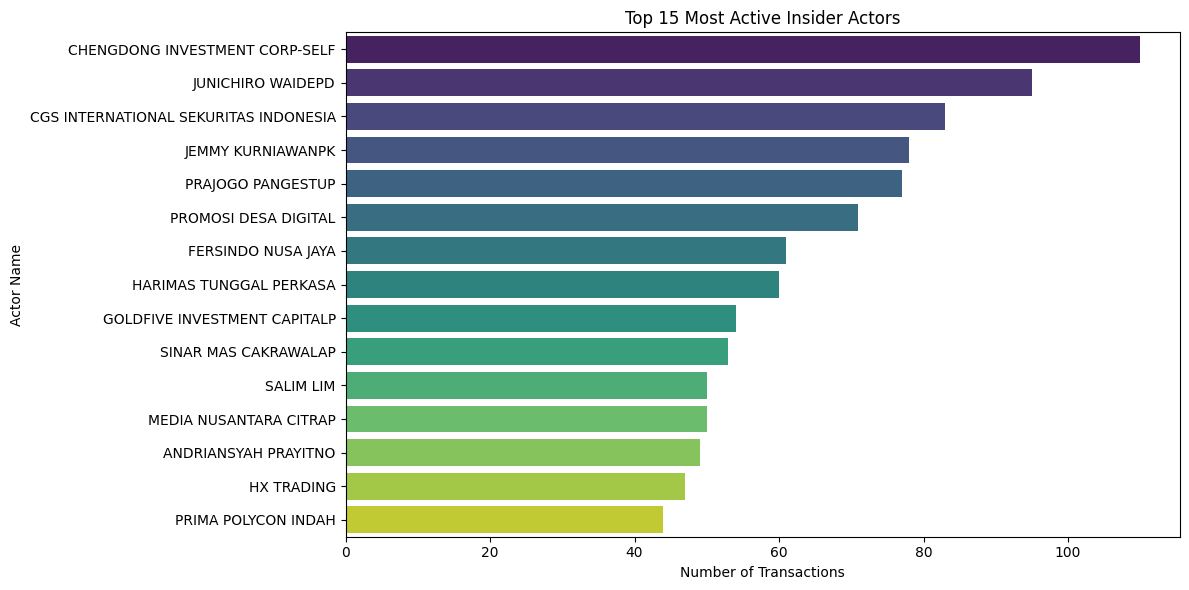

In [18]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_actor,
    x="frequency",
    y="actor_name_final",
    palette="viridis"
)

plt.title("Top 15 Most Active Insider Actors")
plt.xlabel("Number of Transactions")
plt.ylabel("Actor Name")
plt.tight_layout()
plt.show()


# TOP BELI

In [19]:
buy_df = df_clean[df_clean["action_clean"] == "buy"]

actor_freq_buy = (
    buy_df.groupby("actor_name_final")
          .size()
          .reset_index(name="frequency")
          .sort_values("frequency", ascending=False)
          .head(15)
)

actor_freq_buy

,actor_name_final,frequency
226,PRAJOGO PANGESTUP,77
264,SALIM LIM,50
228,PRIMA POLYCON INDAH,44
94,FERSINDO NUSA JAYA,43
53,CGS INTERNATIONAL SEKURITAS INDONESIA,39
218,PATRICK RUDOLF DANNACHERK,38
45,BUANA GRAHA UTAMAP,36
282,SUHENDRA PRAWIRA WIDJAJA,35
113,HARIMAS TUNGGAL PERKASA,35
102,GOLDFIVE INVESTMENT CAPITALP,33


In [20]:
buy_df = df_clean[df_clean['action_clean'] == 'buy']

top_codes = (
    buy_df
    .groupby('code')
    .agg(
        freq_buy=('code', 'count'),
        total_volume_buy=('shares_traded_clean', 'sum'),
        total_value_buy=('transaction_value', 'sum')
    )
    .sort_values('freq_buy', ascending=False)
)

top_codes.sort_values('total_volume_buy', ascending=False).head(15)

,freq_buy,total_volume_buy,total_value_buy
code,,,
GIAA,1,3.156109e+11,2.367082e+13
GMFI,1,8.210017e+10,0.000000e+00
BKSL,27,7.289093e+10,5.734916e+11
SUPA,26,2.301310e+10,7.495873e+11
MCOR,1,2.275156e+10,0.000000e+00
MDIY,25,1.235435e+10,1.271860e+09
BUKA,21,1.030893e+10,9.318362e+11
TPIA,8,9.144970e+09,5.010000e+07
BACA,4,8.404009e+09,4.704000e+11


In [21]:
buyer_stats = (
    buy_df
    .groupby(['code', 'actor_name_final'])
    .agg(
        freq_buy=('code', 'count'),
        total_volume_buy=('shares_traded_clean', 'sum'),
        total_value_buy=('transaction_value', 'sum')
    )
    .sort_values(['code', 'freq_buy'], ascending=[True, False])
)

buyer_stats.head(20)

freq_buy  total_volume_buy  \
code actor_name_final                                              
ABMM LO KHENG HONG                           5      4.910000e+05   
AEGS UOB KAY HIAN                            1      2.000000e+06   
AISA PANGAN SEJAHTERA INVESTAMAP             4      5.500000e+06   
AMMS RADIANT RUBY COMPANY LTD                2      6.300014e+08   
ARCI ABED NEGO                               2      5.040000e+07   
     CHRISTIAN EMANUEL DAVID SOMPIE          2      4.000000e+07   
     HIDAYAT DWIPUTRO SULAKSONO              2      5.040000e+07   
     KENNETH RONALD KENNEDY CRICHTON         2      1.000000e+07   
     RIZKI INDRAKUSUMA                       2      5.040000e+07   
     RUDY SUHENDRA                           2      5.400000e+07   
ARII ABDI ANDREPD                            1      1.000000e+07   
     INFRA ALPHA INVESTINDO                  1      3.190000e+08   
     SUMBER DAYA KEMILAU                     1      1.875383e+08   
ARNA SUPRAKREASI ERADINAMIKA                 4      1.600000e+06   
ASLI WAHANA KONSTRUKSI MANDIRI               2      7.840000e+09   
ASRI MAYBANK SEKURITAS INDONESIA             2      2.472089e+09   
     JOSEPH SANUSI TJONGD                    1      2.000000e+06   
ASRM RAGAM VENTURINDO                        1      6.430007e+06   
ATAP VERAH WAHYUDI S WONG                    1      5.418720e+07   
ATLA YOPHI KURNIAWAN ISWANTOD                1      1.049875e+09   

                                      total_value_buy  
code actor_name_final                                  
ABMM LO KHENG HONG                       0.000000e+00  
AEGS UOB KAY HIAN                        0.000000e+00  
AISA PANGAN SEJAHTERA INVESTAMAP         0.000000e+00  
AMMS RADIANT RUBY COMPANY LTD            1.890004e+10  
ARCI ABED NEGO                           3.780000e+10  
     CHRISTIAN EMANUEL DAVID SOMPIE      3.000000e+10  
     HIDAYAT DWIPUTRO SULAKSONO          3.780000e+10  
     KENNETH RONALD KENNEDY CRICHTON     7.500000e+09  
     RIZKI INDRAKUSUMA                   3.780000e+10  
     RUDY SUHENDRA                       4.050000e+10  
ARII ABDI ANDREPD                        0.000000e+00  
     INFRA ALPHA INVESTINDO              0.000000e+00  
     SUMBER DAYA KEMILAU                 0.000000e+00  
ARNA SUPRAKREASI ERADINAMIKA             0.000000e+00  
ASLI WAHANA KONSTRUKSI MANDIRI           4.312000e+10  
ASRI MAYBANK SEKURITAS INDONESIA         0.000000e+00  
     JOSEPH SANUSI TJONGD                3.220000e+08  
ASRM RAGAM VENTURINDO                    0.000000e+00  
ATAP VERAH WAHYUDI S WONG                2.200000e+10  
ATLA YOPHI KURNIAWAN ISWANTOD            0.000000e+00

# TOP JUALAN

In [22]:
buy_df = df_clean[df_clean["action_clean"] == "sell"]

actor_freq_buy = (
    buy_df.groupby("actor_name_final")
          .size()
          .reset_index(name="frequency")
          .sort_values("frequency", ascending=False)
          .head(15)
)

actor_freq_buy

,actor_name_final,frequency
49,CHENGDONG INVESTMENT CORP-SELF,110
129,JUNICHIRO WAIDEPD,95
125,JEMMY KURNIAWANPK,76
152,MEDIA NUSANTARA CITRAP,50
110,HX TRADING,47
46,CGS INTERNATIONAL SEKURITAS INDONESIA,39
179,PROMOSI DESA DIGITAL,38
203,SINAR MAS CAKRAWALAP,30
81,GLENCORE,27
13,ANDREAS UTOMOPD,27


In [23]:
summary = (
    df_clean
    .groupby(['code', 'actor_name_final', 'action_clean'])
    .agg(
        freq=('code', 'count'),
        total_volume=('shares_traded_clean', 'sum'),
        total_value=('transaction_value', 'sum')
    )
    .reset_index()
)

pivot_summary = summary.pivot_table(
    index=['code', 'actor_name_final'],
    columns='action_clean',
    values=['freq', 'total_volume', 'total_value'],
    fill_value=0
)

pivot_summary.head(20)

freq                                \
action_clean                         buy exercise other  sell transfer   
code actor_name_final                                                    
ABMM LO KHENG HONG                   5.0      0.0   0.0   0.0      0.0   
ACRO TAE SUNG CHUNG                  0.0      1.0   0.0   0.0      0.0   
ADMF MUFG BANKP                      0.0      0.0   0.0   4.0      0.0   
AEGS UOB KAY HIAN                    1.0      0.0   0.0   0.0      0.0   
AHAP SENDRA GUNAWAN                  0.0      0.0   0.0   4.0      0.0   
AISA PANGAN SEJAHTERA INVESTAMAP     4.0      0.0   0.0   0.0      0.0   
AKPI HENRY LIEMK                     0.0      0.0   0.0  14.0      0.0   
AKRA JIMMY TANDYOD                   0.0      0.0   0.0   2.0      0.0   
ALII ANINDITHA ANESTYA BAKRIEK       0.0      0.0   0.0   1.0      0.0   
AMMN ALEXANDER RAMLIEK               0.0      0.0   0.0   1.0      0.0   
     LAL NAVEEN CHANDRAD             0.0      0.0   0.0   2.0      0.0   
     PESONA SUKSES CEMERLANG         0.0      0.0   0.0   0.0      6.0   
     SAJIR                           0.0      0.0   0.0   0.0      2.0   
     SUMBER GEMILANG PERSADA         0.0      0.0   0.0   0.0     10.0   
AMMS HARTONO LIMMANTOROP             0.0      0.0   0.0   1.0      0.0   
     PT MANDARA MAS SEMESTA          0.0      0.0   0.0   2.0      0.0   
     RADIANT RUBY COMPANY LTD        2.0      0.0   0.0   0.0      0.0   
ANTM HANDI SUTANTOD                  0.0      0.0   0.0   1.0      0.0   
ARCI ABED NEGO                       2.0      0.0   0.0   0.0      0.0   
     CHRISTIAN EMANUEL DAVID SOMPIE  2.0      0.0   0.0   0.0      0.0   

                                      total_value                 \
action_clean                                  buy exercise other   
code actor_name_final                                              
ABMM LO KHENG HONG                   0.000000e+00      0.0   0.0   
ACRO TAE SUNG CHUNG                  0.000000e+00      0.0   0.0   
ADMF MUFG BANKP                      0.000000e+00      0.0   0.0   
AEGS UOB KAY HIAN                    0.000000e+00      0.0   0.0   
AHAP SENDRA GUNAWAN                  0.000000e+00      0.0   0.0   
AISA PANGAN SEJAHTERA INVESTAMAP     0.000000e+00      0.0   0.0   
AKPI HENRY LIEMK                     0.000000e+00      0.0   0.0   
AKRA JIMMY TANDYOD                   0.000000e+00      0.0   0.0   
ALII ANINDITHA ANESTYA BAKRIEK       0.000000e+00      0.0   0.0   
AMMN ALEXANDER RAMLIEK               0.000000e+00      0.0   0.0   
     LAL NAVEEN CHANDRAD             0.000000e+00      0.0   0.0   
     PESONA SUKSES CEMERLANG         0.000000e+00      0.0   0.0   
     SAJIR                           0.000000e+00      0.0   0.0   
     SUMBER GEMILANG PERSADA         0.000000e+00      0.0   0.0   
AMMS HARTONO LIMMANTOROP             0.000000e+00      0.0   0.0   
     PT MANDARA MAS SEMESTA          0.000000e+00      0.0   0.0   
     RADIANT RUBY COMPANY LTD        1.890004e+10      0.0   0.0   
ANTM HANDI SUTANTOD                  0.000000e+00      0.0   0.0   
ARCI ABED NEGO                       3.780000e+10      0.0   0.0   
     CHRISTIAN EMANUEL DAVID SOMPIE  3.000000e+10      0.0   0.0   

                                                           total_volume  \
action_clean                                 sell transfer          buy   
code actor_name_final                                                     
ABMM LO KHENG HONG                   0.000000e+00      0.0     491000.0   
ACRO TAE SUNG CHUNG                  0.000000e+00      0.0          0.0   
ADMF MUFG BANKP                      0.000000e+00      0.0          0.0   
AEGS UOB KAY HIAN                    0.000000e+00      0.0    2000000.0   
AHAP SENDRA GUNAWAN                  0.000000e+00      0.0          0.0   
AISA PANGAN SEJAHTERA INVESTAMAP     0.000000e+00      0.0    5500000.0   
AKPI HENRY LIEMK                     4.367625e+08      0.0          0.0   
AKRA JIMMY TANDYOD

# TOP F/I

In [24]:
inst_df = df_clean[df_clean["actor_type"].isin(["institution", "foreign"])]

actor_freq_inst = (
    inst_df.groupby("actor_name_final")
           .size()
           .reset_index(name="frequency")
           .sort_values("frequency", ascending=False)
           .head(15)
)

actor_freq_inst

,actor_name_final,frequency
13,CHENGDONG INVESTMENT CORP-SELF,110
32,JUNICHIRO WAIDEPD,95
27,HX TRADING,47
54,PATRICK RUDOLF DANNACHERK,38
56,PHILLIP SECURITIES,37
7,BANK OF SINGAPORE,35
21,GLENCORE,27
76,UBS SWITZERLAND AG,27
44,MORGAN STANLEY,24
0,A5-DB HOLDINGS,17


# Top Actor by Total Transaction Value

In [25]:
actor_value = (
    df_clean.groupby("actor_name_final")["transaction_value"]
      .sum()
      .reset_index()
      .sort_values("transaction_value", ascending=False)
      .head(15)
)

actor_value

,actor_name_final,transaction_value
102,DANANTARA ASSET MANAGEMENT,2.398847e+13
502,TREASURE GLOBAL INVESTMENTS,6.914100e+12
95,CHENGDONG INVESTMENT CORP-SELF,5.432535e+12
333,MULTI ARTHA PRATAMAP,5.125854e+12
340,NEGARA REPUBLIK INDONESIA,1.949796e+12
372,PANTAI INDAH KAPUK DUAP,1.512500e+12
190,HARIMAS TUNGGAL PERKASA,1.455518e+12
132,ELANG MAHKOTA TEKNOLOGIP,1.054384e+12
282,KREATIF MEDIA KARYAP,9.318362e+11
187,HANWHA GENERAL INSURANCEP,9.142920e+11


In [26]:
print(concat_df['Code'].value_counts().head(15))

Code
BUMI    119
CYBR    118
BSML    112
HALO    108
VTNY     95
ITMA     87
MEDS     80
IMPC     64
ENRG     64
LOPI     57
GPRA     54
SMMA     53
MSIN     52
MAXI     51
CUAN     50
Name: count, dtype: int64


In [27]:
pivot_summary['net_volume'] = (
    pivot_summary['total_volume']['buy'] -
    pivot_summary['total_volume']['sell']
)

pivot_summary[('net_value', '')] = (
    pivot_summary[('total_value', 'buy')] -
    pivot_summary[('total_value', 'sell')]
)

pivot_summary

freq                       \
action_clean                                      buy exercise other  sell   
code actor_name_final                                                        
ABMM LO KHENG HONG                                5.0      0.0   0.0   0.0   
ACRO TAE SUNG CHUNG                               0.0      1.0   0.0   0.0   
ADMF MUFG BANKP                                   0.0      0.0   0.0   4.0   
AEGS UOB KAY HIAN                                 1.0      0.0   0.0   0.0   
AHAP SENDRA GUNAWAN                               0.0      0.0   0.0   4.0   
...                                               ...      ...   ...   ...   
WMUU WIDODO MAKMUR PERKASAP                       1.0      0.0   0.0   8.0   
YOII DANA PENSIUN BANK PEMBANGUNAN DAERAH JATENG  0.0      0.0   0.0  13.0   
YULE BANK OF SINGAPORE                            0.0      0.0   1.0   0.0   
     GEMA BUANA INDONESIA                         0.0      0.0   0.0   1.0   
     SABRINA EVELYN ELIAN                         2.0      0.0   0.0   2.0   

                                                           total_value  \
action_clean                                     transfer          buy   
code actor_name_final                                                    
ABMM LO KHENG HONG                                    0.0          0.0   
ACRO TAE SUNG CHUNG                                   0.0          0.0   
ADMF MUFG BANKP                                       0.0          0.0   
AEGS UOB KAY HIAN                                     0.0          0.0   
AHAP SENDRA GUNAWAN                                   0.0          0.0   
...                                                   ...          ...   
WMUU WIDODO MAKMUR PERKASAP                           0.0          0.0   
YOII DANA PENSIUN BANK PEMBANGUNAN DAERAH JATENG      0.0          0.0   
YULE BANK OF SINGAPORE                                0.0          0.0   
     GEMA BUANA INDONESIA                             0.0          0.0   
     SABRINA EVELYN ELIAN                             0.0  427881600.0   

                                                                       \
action_clean                                     exercise       other   
code actor_name_final                                                   
ABMM LO KHENG HONG                                    0.0         0.0   
ACRO TAE SUNG CHUNG                                   0.0         0.0   
ADMF MUFG BANKP                                       0.0         0.0   
AEGS UOB KAY HIAN                                     0.0         0.0   
AHAP SENDRA GUNAWAN                                   0.0         0.0   
...                                                   ...         ...   
WMUU WIDODO MAKMUR PERKASAP                           0.0         0.0   
YOII DANA PENSIUN BANK PEMBANGUNAN DAERAH JATENG      0.0         0.0   
YULE BANK OF SINGAPORE                                0.0  25000000.0   
     GEMA BUANA INDONESIA                             0.0         0.0   
     SABRINA EVELYN ELIAN                             0.0         0.0   

                                                                         \
action_clean                                              sell transfer   
code actor_name_final                                                     
ABMM LO KHENG HONG                                0.000000e+00      0.0   
ACRO TAE SUNG CHUNG                               0.000000e+00      0.0   
ADMF MUFG BANKP                                   0.000000e+00      0.0   
AEGS UOB KAY HIAN                                 0.000000e+00      0.0   
AHAP SENDRA GUNAWAN                               0.000000e+00      0.0   
...                                                        ...      ...   
WMUU WIDODO MAKMUR PERKASAP                       0.000000e+00      0.0   
YOII DANA PENSIUN BANK PEMBANGUNAN DAERAH JATENG  9.016733e+09      0.0   
YULE BANK OF SINGAPORE                            0.000000e+00      0.0